In [202]:
import numpy as np
from bitarray import bitarray

In [203]:
import math

def dict_size(codigos, block_size):
    num_keys = len(codigos)
    keys_size = num_keys * block_size
    max_value_size = 0
    for key in codigos.keys():
        if len(codigos[key]) > max_value_size:
            max_value_size = len(codigos[key])

    return keys_size + (max_value_size * num_keys)

In [204]:
def count_lenght_sequences(array):
    counter = 0
    current_item = None

    lenghts = {}

    for i, item in enumerate(array):
        if i == 0:
            current_item = item
            counter = 1
        elif current_item!=item:
            if counter not in lenghts.keys():
                lenghts[counter]=1
            else:
                lenghts[counter]=lenghts[counter]+1

            current_item = item
            counter=1
        else:
            counter +=1

    return lenghts

In [205]:
def count_occurrences(array):
    occurrences = {}

    for item in array:
        if item not in occurrences.keys():
            occurrences[item]=1
        else:
            occurrences[item]=occurrences[item]+1

    return occurrences

In [206]:
from bitarray import bitarray
from bitarray.util import ba2int

def split_into_sequences(array, size=8):

    steps = len(array) // size

    sequence = []

    array_copy = array.copy()

    for i in range(steps):
        position = i * size

        sequence.append(ba2int(array_copy[position:position+size].copy()))

    if steps * size < len(array):
        sequence.append(ba2int(array_copy[steps*size:len(array_copy)].copy()))

    return sequence

In [207]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def show_histogram(datos, xlabel, ylabel):
    # Claves y valores del diccionario
    etiquetas = list(datos.keys())
    valores = list(datos.values())

    # Crear la gráfica de barras
    plt.bar(etiquetas, valores)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    #plt.title("Histograma")

    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.show()


In [208]:
def run_lenght_compressor(array, counter_size=8):

    max_encoded_values = (2 ** counter_size)-1
    compressed_array = ''

    counter = None
    current_bit = None

    for i, bit in enumerate(array):
        if i == 0:
            current_bit = bit
            counter = 1
        elif current_bit != bit or counter == max_encoded_values:
            #Añadir conteo de apariciones al vector
            counter_str = str(bin(counter)[2:])
            counter_str = counter_str.zfill(counter_size)

            compressed_array += counter_str
            compressed_array += str(current_bit)

            current_bit = bit
            counter = 1
        else:
            counter += 1

    counter_str = str(bin(counter)[2:])
    counter_str = counter_str.zfill(counter_size)

    compressed_array += counter_str
    compressed_array += str(current_bit)

    return bitarray(compressed_array)


def run_lenght_decompressor(array, counter_size=8):

    steps = len(array) // (counter_size+1)

    decompressed_array = ''

    for i in range(steps):
        position = i * (counter_size+1)

        counter = array[position:position+counter_size]
        bit = array[position+counter_size]

        counter = int(counter.to01(), 2)

        decompressed_array += counter * str(bit)
        
    return bitarray(decompressed_array)

In [209]:
import heapq
from bitarray import bitarray
from bitarray.util import int2ba


# Nodo del árbol de Huffman
class NodoHuffman:
    def __init__(self, simbolo=None, frecuencia=0, izq=None, der=None):
        self.simbolo = simbolo
        self.frecuencia = frecuencia
        self.izq = izq
        self.der = der

    def __lt__(self, otro):
        return self.frecuencia < otro.frecuencia

# Construcción del árbol de Huffman
def construir_arbol(frecuencias):
    heap = [NodoHuffman(sim, freq) for sim, freq in frecuencias.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        n1 = heapq.heappop(heap)
        n2 = heapq.heappop(heap)
        nuevo = NodoHuffman(None, n1.frecuencia + n2.frecuencia, n1, n2)
        heapq.heappush(heap, nuevo)
    return heap[0]

# Generación de códigos Huffman
def generar_codigos(nodo, prefijo='', codigos=None):
    if codigos is None:
        codigos = {}
    if nodo.simbolo is not None:
        codigos[nodo.simbolo] = prefijo
    else:
        generar_codigos(nodo.izq, prefijo + '0', codigos)
        generar_codigos(nodo.der, prefijo + '1', codigos)
    return codigos

def huffman_compressor(array, number_symbols):
    sequences = split_into_sequences(array, number_symbols)
    occurences = count_occurrences(sequences)
    arbol = construir_arbol(occurences)
    codigos = generar_codigos(arbol)

    ba = bitarray()

    for simbolo in sequences:
        ba.extend(codigos[simbolo])

    return codigos, ba


def huffman_decompressor(array, codigos, block_size):
    codigo_a_simbolo = {v: k for k, v in codigos.items()}

    ba = bitarray()

    buffer = ''
    for bit in array:
        buffer += str(bit)
        if buffer in codigo_a_simbolo:
            ba.extend(int2ba(codigo_a_simbolo[buffer], length=block_size, endian='big'))
            buffer = ''

    return ba

In [210]:
def calc_mean_compression(all_arrays, block_size, compressor="huffman"):
    compression = []

    for array in all_arrays:
        if compressor == "huffman":
            codigos, compressed_array  = huffman_compressor(array, block_size)
            compression.append((len(compressed_array)+dict_size(codigos, block_size))/len(array))
        elif compressor == "run-lenght":
            compressed_array = run_lenght_compressor(array, block_size)
            compression.append(len(compressed_array)/len(array))
        else:
            compression.append(-1)
            
        #compression.append(len(compressed_array)/len(array))

    compression = np.array(compression)

    return compression.mean()

In [211]:
array = bitarray('0000001111111110000001000101001100000000111111110000111100000000')
#array = bitarray('0000001111111110000000000000000000000000111111110000111100000000')
#array = bitarray('0000001111111110000001000101')

block_size = 8

#compressed_array = run_lenght_compressor(array, block_size)
codigos, compressed_array  = huffman_compressor(array, block_size)

#decompressed_array = run_lenght_decompressor(compressed_array, block_size)
decompressed_array = huffman_decompressor(compressed_array, codigos, block_size)


print("RAW")
print(array)
print(f"Bits: {len(array)}")  
print(f"Bytes: {len(array.tobytes())}\n")

print("COMPRIMIDO")
print(compressed_array)
#print("Tamaño del bloque (bits): "+str(block_size))
print(f'Tamaño diccionario (bits): {dict_size(codigos, block_size)}')
print(f"Bits: {len(compressed_array)}")  
print(f"Bytes: {len(compressed_array.tobytes())}\n")

print("ESTADISTICAS")
#print(decompressed_array)
print("Compresion correcta: "+str(array==decompressed_array))
print("Tamaño final: "+str(len(compressed_array)/len(array)))

RAW
bitarray('0000001111111110000001000101001100000000111111110000111100000000')
Bits: 64
Bytes: 8

COMPRIMIDO
bitarray('0111110011101001000010')
Tamaño diccionario (bits): 77
Bits: 22
Bytes: 3

ESTADISTICAS
Compresion correcta: True
Tamaño final: 0.34375


In [212]:
import torch

hdv_prototypes_path = "/home/joselu/Universidad/Master_RISCV/TFM/HDC_Accelerator/prototypes"
node = 4
normalized = "_NOT"
normalized = ""

array = torch.load(f'{hdv_prototypes_path}/node_{int(node)}{normalized}_normalized.pt', weights_only=False)

array = array.numpy()

print("Tamaño del vector: "+str(len(array)))

lengths=count_lenght_sequences(array)
print(lengths)

Tamaño del vector: 10000
{3: 575, 1: 2520, 5: 150, 4: 310, 2: 1228, 6: 82, 7: 46, 8: 22, 9: 16, 13: 2, 12: 4, 10: 5, 11: 3, 17: 1}


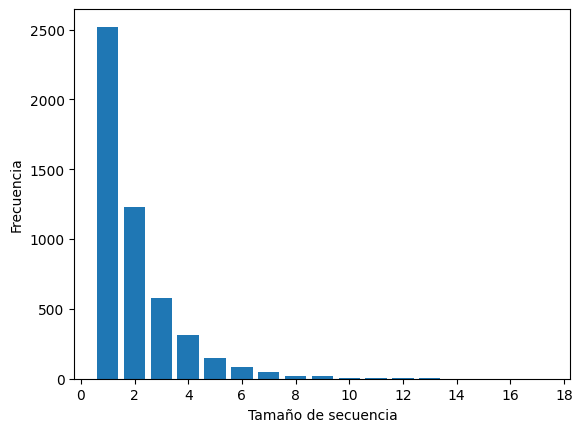

In [213]:
show_histogram(lengths, "Tamaño de secuencia", "Frecuencia")

In [214]:
import torch
import os
from collections import Counter
from bitarray import bitarray
from bitarray.util import int2ba

hdv_prototypes_path = "/home/joselu/Universidad/Master_RISCV/TFM/HDC_Accelerator/prototypes"

files = [f for f in os.listdir(hdv_prototypes_path) if os.path.isfile(os.path.join(hdv_prototypes_path, f))]

normalized_files = [f for f in files if "NOT" not in f]
not_normalized_files = [f for f in files if "NOT" in f]

print(normalized_files)
print(not_normalized_files)

['node_120_normalized.pt', 'node_81_normalized.pt', 'node_150_normalized.pt', 'node_133_normalized.pt', 'node_39_normalized.pt', 'node_20_normalized.pt', 'node_50_normalized.pt', 'node_192_normalized.pt', 'node_149_normalized.pt', 'node_14_normalized.pt', 'node_25_normalized.pt', 'node_89_normalized.pt', 'node_113_normalized.pt', 'node_194_normalized.pt', 'node_142_normalized.pt', 'node_16_normalized.pt', 'node_123_normalized.pt', 'node_88_normalized.pt', 'node_162_normalized.pt', 'node_184_normalized.pt', 'node_85_normalized.pt', 'node_132_normalized.pt', 'node_33_normalized.pt', 'node_38_normalized.pt', 'node_118_normalized.pt', 'node_151_normalized.pt', 'node_87_normalized.pt', 'node_153_normalized.pt', 'node_86_normalized.pt', 'node_77_normalized.pt', 'node_189_normalized.pt', 'node_40_normalized.pt', 'node_75_normalized.pt', 'node_54_normalized.pt', 'node_24_normalized.pt', 'node_8_normalized.pt', 'node_117_normalized.pt', 'node_18_normalized.pt', 'node_78_normalized.pt', 'node_11

In [215]:
all_arrays=[]

for file in normalized_files:
    try:
        array = torch.load(f'{hdv_prototypes_path}/{file}', weights_only=False)
        array = array.numpy()

        #Pasar de (-1, 1) a (0, 1)
        array = (array + 1)//2

        bit_array = bitarray()

        for n in array:
            bit_array.extend(str(n))

        all_arrays.append(bit_array)
    except Exception as e:
        print(str(e))

'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'


In [216]:
all_lenghts = {}

for array in all_arrays:
    lengths = count_lenght_sequences(array)
    all_lenghts = dict(Counter(all_lenghts)+Counter(lengths))

print(all_lenghts)

{5: 16139, 2: 126006, 1: 256654, 3: 59846, 6: 7641, 4: 31284, 9: 1275, 8: 2036, 7: 4846, 10: 820, 11: 293, 13: 150, 12: 169, 17: 77, 15: 56, 14: 49, 16: 6}


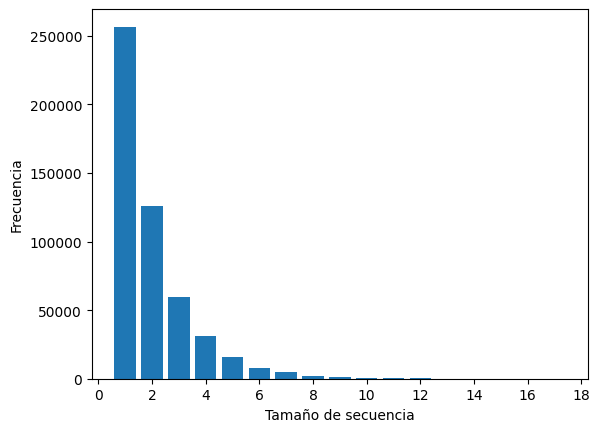

In [217]:
show_histogram(all_lenghts, "Tamaño de secuencia", "Frecuencia")

In [218]:
all_occurrences = {}

for array in all_arrays:
    sequences = split_into_sequences(array, 16)
    occurences = count_occurrences(sequences)
    all_occurrences = dict(Counter(all_occurrences)+Counter(occurences))

print(all_occurrences)

{1996: 20, 46444: 4, 19284: 30, 2312: 6, 6350: 5, 19476: 15, 53971: 1, 33214: 10, 36698: 22, 35137: 7, 7702: 8, 34902: 11, 15725: 19, 2431: 3, 51889: 3, 45388: 10, 15884: 6, 17124: 6, 34429: 4, 16908: 41, 5002: 3, 1316: 31, 45248: 2, 12228: 7, 12838: 7, 2298: 55, 36843: 57, 16633: 15, 3376: 6, 10329: 6, 18464: 8, 21172: 2, 24137: 31, 12740: 9, 39968: 42, 43397: 34, 64914: 3, 8738: 13, 17770: 8, 57180: 8, 28136: 1, 62212: 43, 7899: 3, 18717: 10, 33544: 1, 25121: 32, 42618: 6, 17091: 7, 22114: 10, 61510: 25, 41004: 2, 45458: 15, 10279: 21, 13638: 6, 5795: 16, 51540: 19, 2459: 4, 26837: 1, 45355: 4, 10362: 3, 13496: 12, 23616: 11, 61805: 15, 51405: 16, 2236: 5, 18560: 10, 41200: 40, 2011: 59, 11287: 10, 42651: 14, 34537: 13, 35341: 8, 9371: 8, 57795: 1, 21826: 8, 17522: 12, 19074: 7, 30042: 13, 33338: 2, 4261: 36, 17533: 21, 53827: 4, 34456: 3, 33257: 7, 34592: 2, 1092: 5, 49722: 45, 23362: 18, 20493: 2, 38246: 1, 41285: 1, 6161: 6, 33929: 8, 4843: 3, 19200: 27, 47664: 9, 17699: 11, 50481

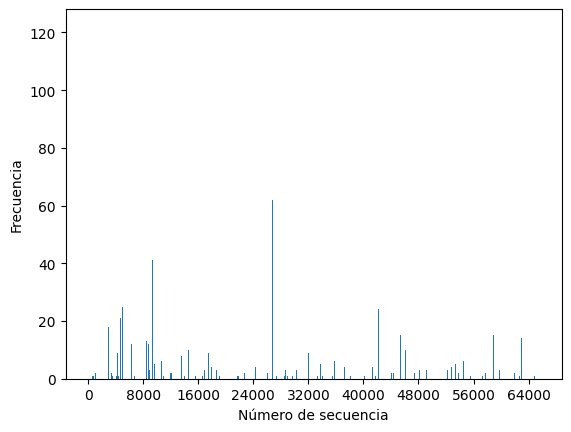

In [219]:
show_histogram(all_occurrences, "Número de secuencia", "Frecuencia")

In [220]:
block_size = 16

mean_compression = calc_mean_compression(all_arrays, block_size)

print("Tamaño del bloque (bits): "+str(block_size))
print(f"Bits: {len(array)}")  
print(f"Bytes: {len(array.tobytes())}\n")
print("Mean final size after compression: "+str(mean_compression))

Tamaño del bloque (bits): 16
Bits: 10000
Bytes: 1250

Mean final size after compression: 2.1973078431372546


In [221]:
compression = {}

for i in range(4, 65, 2): 
    compression[i] = calc_mean_compression(all_arrays, i)

print(compression)

{4: np.float64(1.0087333333333333), 6: np.float64(1.0725098039215686), 8: np.float64(1.4267411764705884), 10: np.float64(2.1266784313725493), 12: np.float64(2.415392156862745), 14: np.float64(2.3463872549019613), 16: np.float64(2.1973078431372546), 18: np.float64(2.064088235294117), 20: np.float64(1.8983745098039215), 22: np.float64(1.8142999999999998), 24: np.float64(1.7418999999999991), 26: np.float64(1.6812999999999996), 28: np.float64(1.6314000000000004), 30: np.float64(1.5853999999999995), 32: np.float64(1.5450999999999995), 34: np.float64(1.5123000000000006), 36: np.float64(1.4778), 38: np.float64(1.4535999999999998), 40: np.float64(1.3994000000000009), 42: np.float64(1.3844999999999998), 44: np.float64(1.3651999999999993), 46: np.float64(1.3478), 48: np.float64(1.3329000000000002), 50: np.float64(1.3144), 52: np.float64(1.3060999999999998), 54: np.float64(1.2949999999999995), 56: np.float64(1.2811000000000003), 58: np.float64(1.2719000000000003), 60: np.float64(1.260300000000000

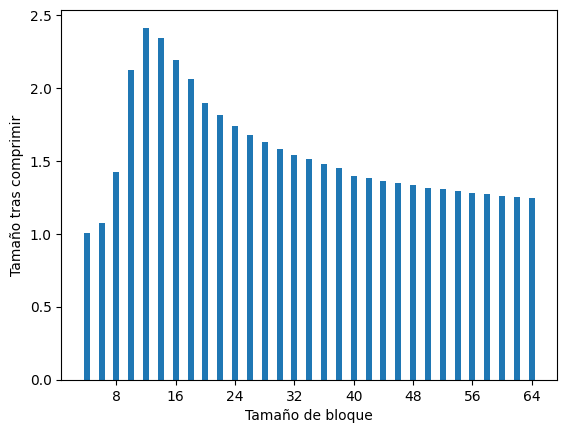

In [222]:
show_histogram(compression, "Tamaño de bloque", "Tamaño tras comprimir")

In [223]:
all_arrays = []

for file in not_normalized_files:
    try:
        array = torch.load(f'{hdv_prototypes_path}/{file}', weights_only=False)
        array = array.numpy()

        bit_array = bitarray()

        for n in array:
            bit_array.extend(int2ba(int(n), length=8, endian='big', signed=True))

        all_arrays.append(bit_array)

    except Exception as e:
        print("Error al cargar el archivo: "+str(file)+" "+str(e))

In [224]:
all_lenghts = {}

for array in all_arrays:
    lengths = count_lenght_sequences(array)
    all_lenghts = dict(Counter(all_lenghts)+Counter(lengths))

print(all_lenghts)

{3: 486399, 2: 904484, 1: 2085710, 4: 284666, 7: 48773, 6: 73162, 9: 4057, 5: 133236, 8: 14149, 12: 559, 13: 605, 15: 583, 16: 219, 10: 1711, 14: 673, 20: 5, 11: 868, 17: 149, 18: 34, 21: 15, 25: 13, 23: 47, 22: 55, 24: 17, 31: 7, 19: 27, 29: 5, 48: 1, 30: 6, 26: 5, 32: 4, 40: 1, 39: 1, 33: 1, 28: 1}


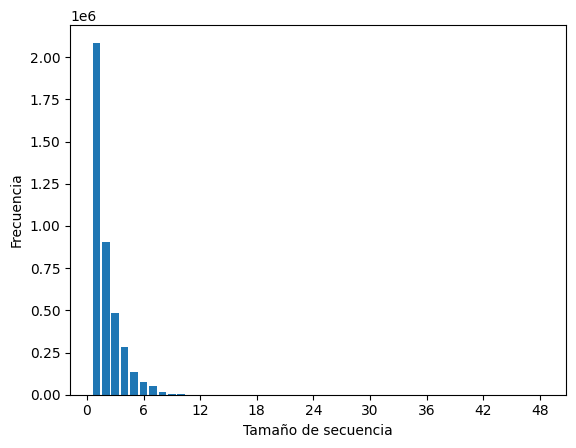

In [225]:
show_histogram(all_lenghts, "Tamaño de secuencia", "Frecuencia")

In [226]:
all_occurrences = {}

for array in all_arrays:
    sequences = split_into_sequences(array, 8)
    occurences = count_occurrences(sequences)
    all_occurrences = dict(Counter(all_occurrences)+Counter(occurences))

print(all_occurrences)

{230: 3055, 226: 11217, 242: 8452, 30: 8897, 16: 10243, 24: 8731, 6: 4004, 28: 6542, 252: 9669, 4: 8408, 2: 5040, 8: 3643, 236: 7147, 244: 12864, 240: 12756, 26: 2558, 250: 4062, 254: 5244, 12: 10608, 248: 3709, 18: 6012, 246: 4564, 228: 7912, 234: 11000, 20: 5896, 22: 8442, 238: 7159, 14: 7091, 0: 4961, 232: 11835, 10: 3342, 166: 13508, 170: 619, 88: 4307, 90: 9852, 54: 873, 84: 3891, 64: 1018, 176: 4669, 202: 883, 58: 3639, 210: 10521, 60: 1089, 208: 10537, 42: 11283, 50: 4403, 168: 5598, 48: 7926, 204: 5542, 172: 5118, 68: 4505, 86: 631, 182: 13354, 190: 9617, 34: 11345, 224: 11250, 52: 4327, 74: 9896, 82: 690, 194: 5225, 66: 7137, 196: 1118, 70: 4156, 46: 8066, 80: 3499, 186: 5465, 200: 1051, 178: 5001, 222: 14800, 76: 609, 72: 7217, 40: 1501, 206: 5622, 36: 1402, 44: 7984, 180: 649, 174: 721, 188: 5837, 214: 14900, 216: 1601, 184: 9749, 62: 4040, 218: 1521, 220: 1447, 198: 4803, 38: 1506, 78: 3827, 32: 8901, 212: 10521, 56: 978, 192: 1052, 164: 9313, 92: 6837, 213: 5014, 181: 1404

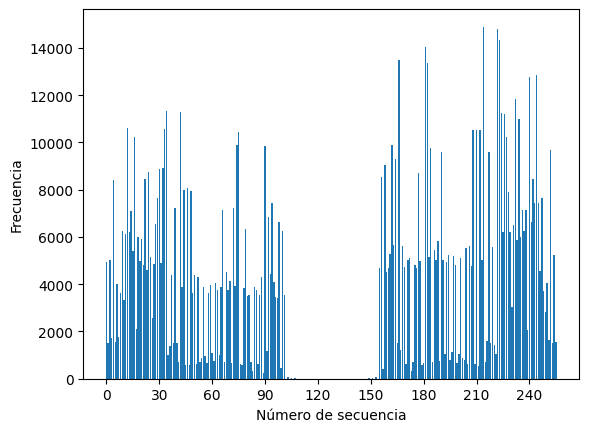

In [227]:
show_histogram(all_occurrences, "Número de secuencia", "Frecuencia")

In [228]:
block_size = 8

mean_compression = calc_mean_compression(all_arrays, block_size)

print("Tamaño del bloque (bits): "+str(block_size))
print(f"Bits: {len(array)}")  
print(f"Bytes: {len(array.tobytes())}\n")
print("Mean final size after compression: "+str(mean_compression))

Tamaño del bloque (bits): 8
Bits: 80000
Bytes: 10000

Mean final size after compression: 0.3598906862745099


In [229]:
compression = {}

for i in range(4, 65, 2):
    compression[i] = calc_mean_compression(all_arrays, i)

print(compression)

{4: np.float64(0.6558877450980392), 6: np.float64(0.7280377450980391), 8: np.float64(0.3598906862745099), 10: np.float64(0.6918556372549018), 12: np.float64(0.5814522058823529), 14: np.float64(0.778629044117647), 16: np.float64(0.48681053921568623), 18: np.float64(0.8898566176470587), 20: np.float64(0.7850301470588236), 22: np.float64(1.0098930147058824), 24: np.float64(0.7264273284313725), 26: np.float64(1.1065099264705882), 28: np.float64(1.0257219362745098), 30: np.float64(1.1801579656862746), 32: np.float64(0.9665802696078432), 34: np.float64(1.2261317401960783), 36: np.float64(1.1612623774509805), 38: np.float64(1.26671875), 40: np.float64(1.0960848039215687), 42: np.float64(1.2930055147058825), 44: np.float64(1.2323349264705883), 46: np.float64(1.3244642156862745), 48: np.float64(1.174472181372549), 50: np.float64(1.3396828431372543), 52: np.float64(1.2924267156862743), 54: np.float64(1.3438050245098043), 56: np.float64(1.2345689950980392), 58: np.float64(1.3367689950980388), 60:

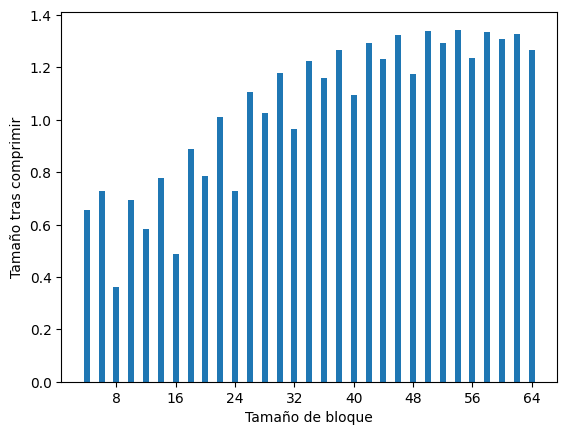

In [230]:
show_histogram(compression, "Tamaño de bloque", "Tamaño tras comprimir")